# Análise do dados

##### IMPORTAÇÃO DAS BIBLIOTECAS

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

###### IMPORTAÇÃO DOS DADOS TRATADOS

In [2]:
clientes = pd.read_csv("/content/clientes_limpos.csv")
funcionarios = pd.read_csv("/content/funcionarios_limpos.csv")
atendimentos = pd.read_csv("/content/atendimentos_limpos.csv")
metas = pd.read_csv("/content/metas_limpos.csv")

In [3]:
print(atendimentos.dtypes)

id_atendimento       int64
id_cliente           int64
id_funcionario       int64
unidade             object
servico             object
valor              float64
data                object
forma_pagamento     object
dtype: object


In [4]:
atendimentos["data"] = pd.to_datetime(
    atendimentos["data"]
)

##### KPIs GERAIS

In [5]:
print("KPIs GERAIS")
print("=====================================")

faturamento_total = atendimentos["valor"].sum()
print(f"Faturamento total R$: {faturamento_total},.2f")
print("=====================================")

ticket_medio = atendimentos["valor"].mean()
print(f"Ticket Médio: R$ {ticket_medio:,.2f}")
print("=====================================")

total_atendimentos = len(atendimentos)
print(f"Total de Atendimentos: {total_atendimentos}")
print("=====================================")

clientes_unicos = atendimentos["id_cliente"].nunique()
print(f"Clientes Únicos: {clientes_unicos}")


KPIs GERAIS
Faturamento total R$: 1106272.05,.2f
Ticket Médio: R$ 55.49
Total de Atendimentos: 19935
Clientes Únicos: 2995


##### FATURAMENTO POR UNIDADE

In [10]:
print("FATURAMENTO POR UNIDADE")
print("=======================")

faturamento_unidade = atendimentos.groupby("unidade")["valor"].sum().sort_values(ascending=False)
print(faturamento_unidade)

FATURAMENTO POR UNIDADE
unidade
Ceilândia     280897.33
Asa Sul       280627.19
Taguatinga    272374.59
Asa Norte     272372.94
Name: valor, dtype: float64


##### SERVIÇOS MAIS VENDIDOS

In [11]:
print("SERVIÇOS MAIS VENDIDOS")
print("=====================================")

servicos_top = atendimentos["servico"].value_counts()
print(servicos_top)

SERVIÇOS MAIS VENDIDOS
servico
Pigmentação    4054
Hidratação     3994
Sobrancelha    3980
Barba          3965
Corte          3942
Name: count, dtype: int64


##### FORMAS DE PAGAMENTO

In [12]:
print("FORMAS DE PAGAMENTO")
print("=====================================")

pagamentos = atendimentos["forma_pagamento"].value_counts()
print(pagamentos)


FORMAS DE PAGAMENTO
forma_pagamento
Cartão      6734
Dinheiro    6608
Pix         6593
Name: count, dtype: int64


##### FATURAMENTO MENSAL

In [15]:
atendimentos["ano_mes"] = atendimentos["data"].dt.to_period("M")

faturamento_mensal = atendimentos.groupby("ano_mes")["valor"].sum()
print("FATURAMENTO MENSAL")
print("=====================================")

print(faturamento_mensal)


FATURAMENTO MENSAL
ano_mes
2024-05    30455.32
2024-06    46107.21
2024-07    48884.22
2024-08    41887.00
2024-09    46915.68
2024-10    46588.80
2024-11    47717.28
2024-12    45437.65
2025-01    47693.05
2025-02    44813.19
2025-03    47515.70
2025-04    44144.39
2025-05    44560.08
2025-06    42147.44
2025-07    47493.35
2025-08    44981.31
2025-09    46605.94
2025-10    44468.91
2025-11    46858.89
2025-12    45426.10
2026-01    48121.96
2026-02    42885.75
2026-03    48727.89
2026-04    45823.93
2026-05    20011.01
Freq: M, Name: valor, dtype: float64


##### TOP FUNCIONÁRIOS

In [17]:
top_funcionarios = atendimentos.groupby("id_funcionario")["valor"].sum().sort_values(ascending=False)
print("TOP FUNCIONÁRIOS")
print("=====================================")

print(top_funcionarios.head(10))


TOP FUNCIONÁRIOS
id_funcionario
38    30699.54
17    30593.20
25    29905.45
32    29570.98
30    29473.51
37    29275.05
24    29155.12
19    28997.92
11    28885.72
28    28874.68
Name: valor, dtype: float64


### GRÁFICO - FATURAMENTO POR UNIDADE

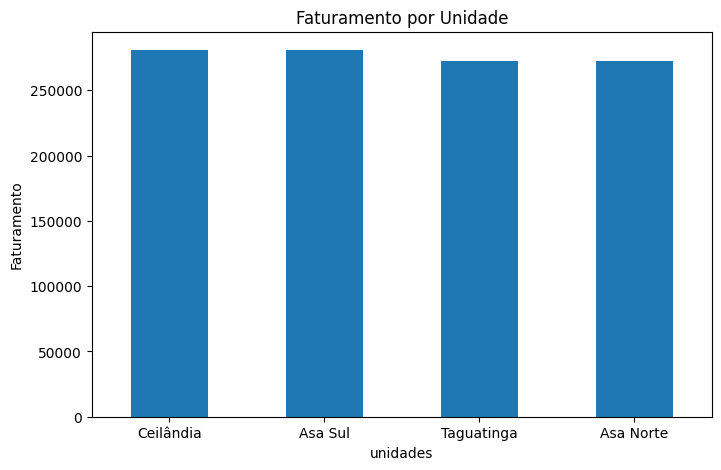

In [22]:
plt.figure(figsize=(8,5))
faturamento_unidade.plot(kind="bar")
plt.title("Faturamento por Unidade")
plt.xlabel("unidades")
plt.ylabel("Faturamento")
plt.xticks(rotation=0)
plt.show()


#### GRÁFICO - SERVIÇOS MAIS VENDIDOS

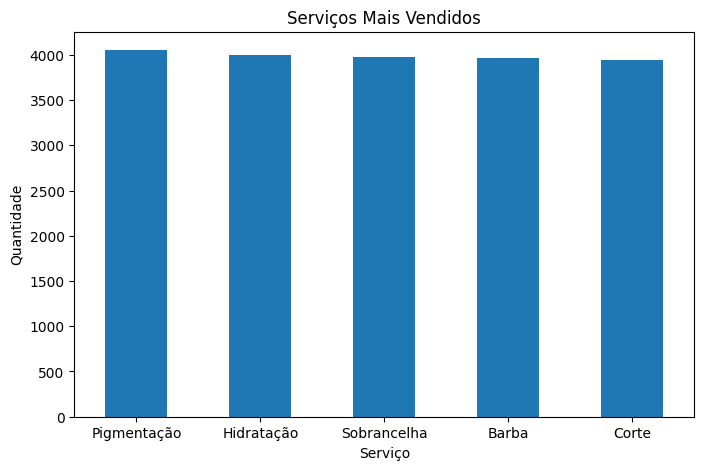

In [24]:
plt.figure(figsize=(8,5))
servicos_top.plot(kind="bar")
plt.title("Serviços Mais Vendidos")
plt.xlabel("Serviço")
plt.ylabel("Quantidade")
plt.xticks(rotation=0)
plt.show()

#### GRÁFICO - FATURAMENTO MENSAL

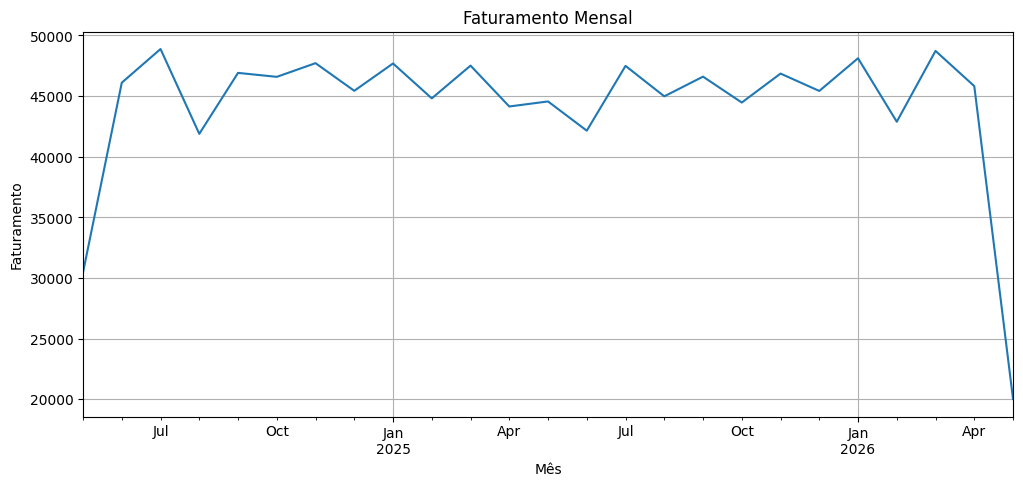

In [28]:
plt.figure(figsize=(12,5))
faturamento_mensal.plot()
plt.title("Faturamento Mensal")
plt.xlabel("Mês")
plt.ylabel("Faturamento")
plt.grid()
plt.show()

# EXPORTAÇÃO DOS KPIs

In [30]:
kpis = pd.DataFrame({
"KPI": [
        "Faturamento Total",
        "Ticket Médio",
        "Total Atendimentos",
        "Clientes Únicos"
    ],
    "Valor": [
        faturamento_total,
        ticket_medio,
        total_atendimentos,
        clientes_unicos
    ]
})

kpis.to_csv("kpis.csv",index=False)

print("\nArquivo de KPIs exportado!")


Arquivo de KPIs exportado!
